found files: ['..\\train.pkl', '..\\val.pkl', '..\\test.pkl']
data shape: (271452, 17)
child_col: 子评论数
count_gt10: 3342
count_eq0: 244764

by split:
        total  gt10     eq0
split                      
test    27145   349   24394
train  217162  2649  195961
val     27145   344   24409


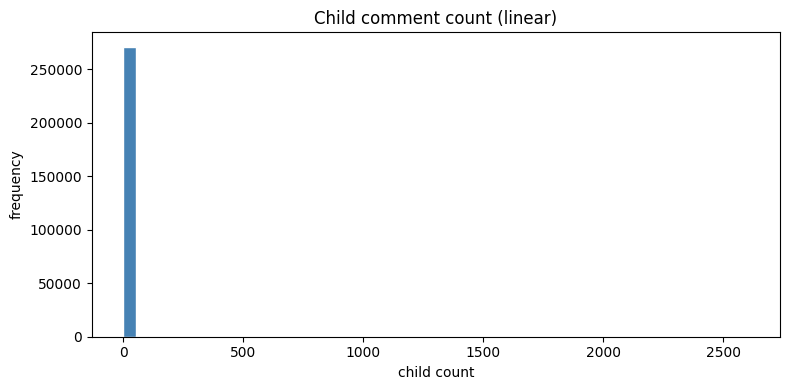

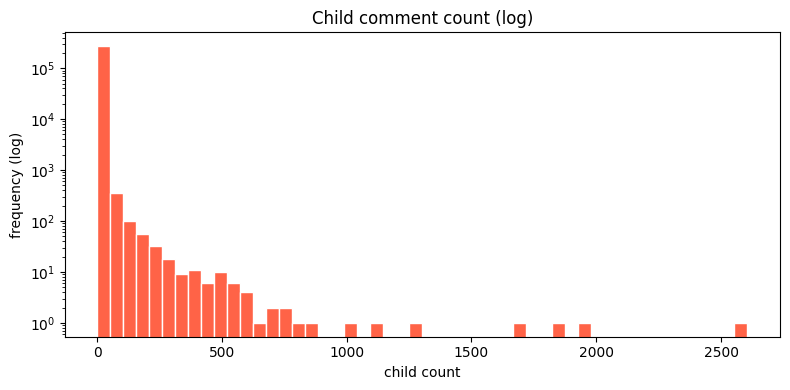

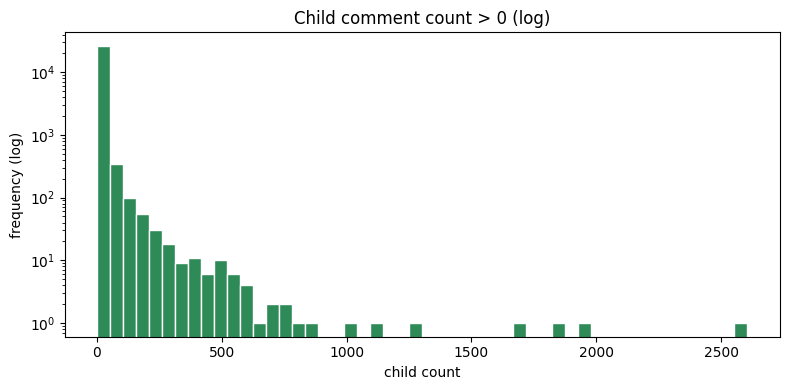

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# If running from notebooks/, set root = Path('..')
root = Path('..')

# Look for train/val/test pkl in current dir or data/
candidates = [
    root / 'train.pkl', root / 'val.pkl', root / 'test.pkl',
]
existing = [f for f in candidates if f.exists()]
print('found files:', [str(f) for f in existing])

if not existing:                                                                                                                                                           
    raise FileNotFoundError('train/val/test pkl not found; check root path')                                                                                               
                                                                                                                                                                            
# Load and concat                                                                                                                                                          
dfs = []                                                                                                                                                                   
for f in existing:                                                                                                                                                         
    df = pd.read_pickle(f)                                                                                                                                                 
    df['split'] = f.stem                                                                                                                                                   
    dfs.append(df)                                                                                                                                                         
                                                                                                                                                                            
data = pd.concat(dfs, ignore_index=True)                                                                                                                                   
print('data shape:', data.shape)                                                                                                                                           
                                                                                                                                                                            
# Auto-detect child comment count column                                                                                                                                   
cols = list(data.columns)                                                                                                                                                  
                                                                                                                                                                            
def find_child_col(cols):                                                                                                                                                  
    if '子评论数' in cols:                                                                                                                                                 
        return '子评论数'                                                                                                                                                  
    # fallback: find first column containing these substrings                                                                                                              
    for c in cols:
        sc = str(c)                                                                                                                                                        
        if '子评论' in sc or '子評' in sc:                                                                                                                                 
            return c                                                                                                                                                       
    return None                                                                                                                                                            
                                                                                                                                                                            
child_col = find_child_col(cols)                                                                                                                                           
if child_col is None:                                                                                                                                                      
    raise KeyError(f'child comment count column not found; columns={cols}')                                                                                                
                                                                                                                                                                            
child = data[child_col]                                                                                                                                                    
                                                                                                                                                                            
count_gt10 = int((child > 10).sum())                                                                                                                                       
count_eq0 = int((child == 0).sum())                                                                                                                                        
                                                                                                                                                                            
print('child_col:', child_col)                                                                                                                                             
print('count_gt10:', count_gt10)                                                                                                                                           
print('count_eq0:', count_eq0)                                                                                                                                             
                                                                                                                                                                            
# By split summary                                                                                                                                                         
summary = data.groupby('split')[child_col].agg(                                                                                                                            
    total='count',                                                                                                                                                         
    gt10=lambda s: (s > 10).sum(),                                                                                                                                         
    eq0=lambda s: (s == 0).sum(),                                                                                                                                          
)                                                                                                                                                                          
print('\nby split:')                                                                                                                                                       
print(summary)
                                                                                                                                                                            
# Distribution: linear                                                                                                                                                     
plt.figure(figsize=(8, 4))                                                                                                                                                 
plt.hist(child, bins=50, color='steelblue', edgecolor='white')                                                                                                             
plt.title('Child comment count (linear)')                                                                                                                                  
plt.xlabel('child count')                                                                                                                                                  
plt.ylabel('frequency')                                                                                                                                                    
plt.tight_layout()                                                                                                                                                         
plt.show()                                                                                                                                                                 
                                                                                                                                                                            
# Distribution: log                                                                                                                                                        
plt.figure(figsize=(8, 4))                                                                                                                                                 
plt.hist(child, bins=50, color='tomato', edgecolor='white')                                                                                                                
plt.yscale('log')                                                                                                                                                          
plt.title('Child comment count (log)')                                                                                                                                     
plt.xlabel('child count')                                                                                                                                                  
plt.ylabel('frequency (log)')                                                                                                                                              
plt.tight_layout()                                                                                                                                                         
plt.show()                                                                                                                                                                 
                                                                                                                                                                            
# Distribution: >0 only (log)                                                                                                                                              
plt.figure(figsize=(8, 4))                                                                                                                                                 
plt.hist(child[child > 0], bins=50, color='seagreen', edgecolor='white')                                                                                                   
plt.yscale('log')                                                                                                                                                          
plt.title('Child comment count > 0 (log)')                                                                                                                                 
plt.xlabel('child count')                                                                                                                                                  
plt.ylabel('frequency (log)')                                                                                                                                              
plt.tight_layout()                                                                                                                                                         
plt.show()   

found files: ['..\\train.pkl', '..\\val.pkl', '..\\test.pkl']
data shape: (271452, 17)
like_col: 点赞数
count_gt10: 3522
count_eq0: 180260

by split:
        total  gt10     eq0
split                      
test    20159   352   17938
train  161604  2787  144294
val     20221   383   18028


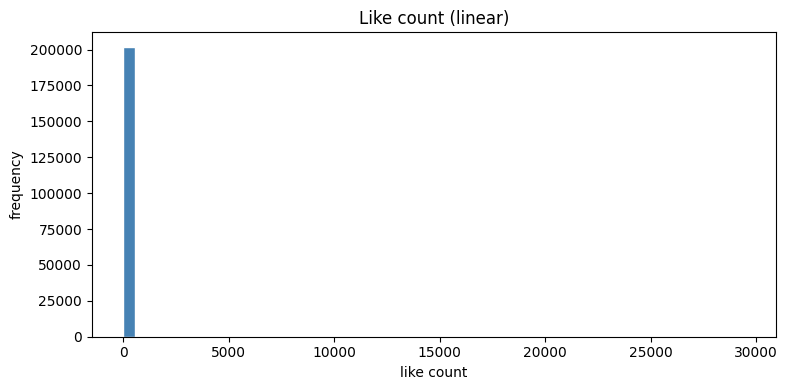

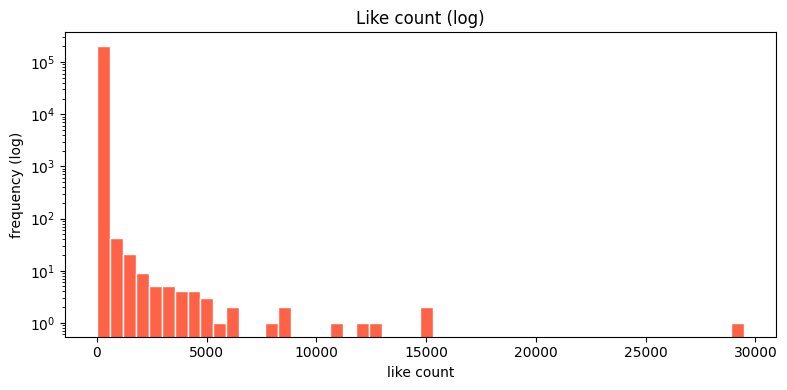

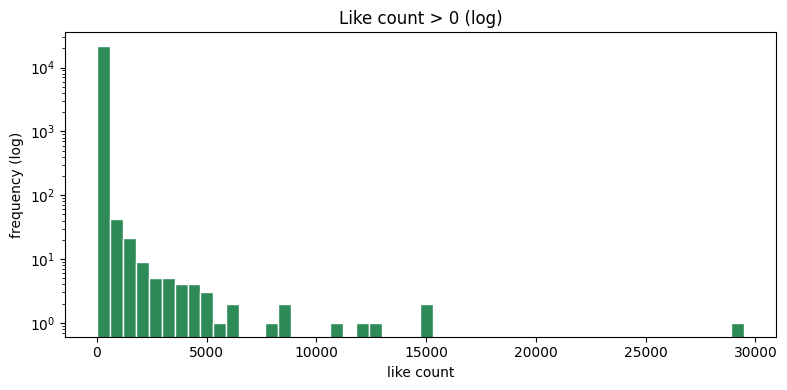

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# If running from notebooks/, set root = Path('..')
root = Path('..')

# Look for train/val/test pkl in current dir or data/
candidates = [
    root / 'train.pkl', root / 'val.pkl', root / 'test.pkl',
    root / 'data' / 'train.pkl', root / 'data' / 'val.pkl', root / 'data' / 'test.pkl',
]                                                                                                                                                                          
existing = [f for f in candidates if f.exists()]                                                                                                                           
print('found files:', [str(f) for f in existing])                                                                                                                          
                                                                                                                                                                            
if not existing:                                                                                                                                                           
    raise FileNotFoundError('train/val/test pkl not found; check root path')                                                                                               
                                                                                                                                                                            
# Load and concat                                                                                                                                                          
dfs = []                                                                                                                                                                   
for f in existing:                                                                                                                                                         
    df = pd.read_pickle(f)                                                                                                                                                 
    df['split'] = f.stem                                                                                                                                                   
    dfs.append(df)                                                                                                                                                         
                                                                                                                                                                            
data = pd.concat(dfs, ignore_index=True)                                                                                                                                   
print('data shape:', data.shape)                                                                                                                                           
                                                                                                                                                                            
# Auto-detect like count column                                                                                                                                            
cols = list(data.columns)                                                                                                                                                  
                                                                                                                                                                            
def find_like_col(cols):                                                                                                                                                   
    if '点赞数' in cols:                                                                                                                                                   
        return '点赞数'                                                                                                                                                    
    # fallback: find first column containing these substrings                                                                                                              
    for c in cols:                                                                                                                                                         
        sc = str(c)                                                                                                                                                        
        if '点赞' in sc or '讚' in sc:                                                                                                                                     
            return c                                                                                                                                                       
    return None                                                                                                                                                            
                                                                                                                                                                            
like_col = find_like_col(cols)                                                                                                                                             
if like_col is None:                                                                                                                                                       
    raise KeyError(f'like count column not found; columns={cols}')                                                                                                         
                                                                                                                                                                            
likes = data[like_col]                                                                                                                                                     

count_gt10 = int((likes > 10).sum())                                                                                                                                       
count_eq0 = int((likes == 0).sum())                                                                                                                                        
                                                                                                                                                                            
print('like_col:', like_col)                                                                                                                                               
print('count_gt10:', count_gt10)                                                                                                                                           
print('count_eq0:', count_eq0)                                                                                                                                             
                                                                                                                                                                            
# By split summary                                                                                                                                                         
summary = data.groupby('split')[like_col].agg(                                                                                                                             
    total='count',                                                                                                                                                         
    gt10=lambda s: (s > 10).sum(),                                                                                                                                         
    eq0=lambda s: (s == 0).sum(),                                                                                                                                          
)                                                                                                                                                                          
print('\nby split:')                                                                                                                                                       
print(summary)                                                                                                                                                             
                                                                                                                                                                            
# Distribution: linear                                                                                                                                                     
plt.figure(figsize=(8, 4))
plt.hist(likes, bins=50, color='steelblue', edgecolor='white')                                                                                                             
plt.title('Like count (linear)')                                                                                                                                           
plt.xlabel('like count')                                                                                                                                                   
plt.ylabel('frequency')                                                                                                                                                    
plt.tight_layout()                                                                                                                                                         
plt.show()                                                                                                                                                                 
                                                                                                                                                                            
# Distribution: log                                                                                                                                                        
plt.figure(figsize=(8, 4))                                                                                                                                                 
plt.hist(likes, bins=50, color='tomato', edgecolor='white')                                                                                                                
plt.yscale('log')                                                                                                                                                          
plt.title('Like count (log)')                                                                                                                                              
plt.xlabel('like count')                                                                                                                                                   
plt.ylabel('frequency (log)')                                                                                                                                              
plt.tight_layout()                                                                                                                                                         
plt.show()
                                                                                                                                                                            
# Distribution: >0 only (log)                                                                                                                                              
plt.figure(figsize=(8, 4))                                                                                                                                                 
plt.hist(likes[likes > 0], bins=50, color='seagreen', edgecolor='white')                                                                                                   
plt.yscale('log')                                                                                                                                                          
plt.title('Like count > 0 (log)')                                                                                                                                          
plt.xlabel('like count')                                                                                                                                                   
plt.ylabel('frequency (log)')                                                                                                                                              
plt.tight_layout()                                                                                                                                                         
plt.show()   